# 07 - Divergence study: does the topological veto inform?

Divergence = NS promotes AND the topology vetoes. Rates per arm with exact Wilson intervals (n is small: the interval IS the result). A zero rate is a valid finding and is discussed, never hidden.

In [1]:
# PROMETHEUS-V2 setup cell — run FIRST. On Colab with GPU desired:
# Runtime > Change runtime type > GPU, then run this.
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/REPLACE-USER/PROMETHEUS-NS.git"  # <- edit

if IN_COLAB:
    if not Path("/content/PROMETHEUS-NS/.git").exists():
        subprocess.run(["git", "clone", REPO_URL, "/content/PROMETHEUS-NS"],
                       check=True)
    os.chdir("/content/PROMETHEUS-NS")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", "requirements.txt"], check=True)
    print("Colab setup complete.")
else:
    try:
        import torch, ripser, scipy, networkx  # noqa: F401
        print("Local environment OK.")
    except ImportError as exc:
        raise SystemExit(f"Missing dependency ({exc}). Run `make setup`.")


Local environment OK.


In [2]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO / "config.yaml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
os_cwd = Path.cwd()

FIG_DIR = REPO / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_jsonl(path):
    path = Path(path)
    if not path.is_file():
        return []
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows


def save_figure(fig, name):
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    print(f"figure -> {out}")


TOPO = load_jsonl(REPO / "logs" / "topo.jsonl")
DECISIONS = load_jsonl(REPO / "logs" / "promotion_decisions.jsonl")
print(f"topo.jsonl rows: {len(TOPO)} | decisions: {len(DECISIONS)}")


topo.jsonl rows: 6 | decisions: 6


In [3]:
from statistics import NormalDist
import math


def wilson(successes, total, ci=0.95):
    if total == 0:
        return 0.0, 1.0
    z = NormalDist().inv_cdf(1 - (1 - ci) / 2)
    p = successes / total
    denom = 1 + z * z / total
    centre = (p + z * z / (2 * total)) / denom
    spread = z * math.sqrt(p * (1 - p) / total + z * z / (4 * total * total))
    return max(0, centre - spread), min(1, centre + spread)


dec_by_round = {d["round_id"]: d for d in DECISIONS}
rows = []
for r in TOPO:
    dec = dec_by_round.get(r["round_id"], {})
    rows.append({
        "round": r["round_id"],
        "stress": r.get("stress_mode"),
        "ns_promoted": bool(dec.get("ns_promote", False)),
        "topo_veto": bool(r.get("veto", False)),
        "establish_baseline": bool(r.get("establish_baseline", False)),
        "ppl_gain": r.get("relative_ppl_gain", 0.0),
    })
table = pd.DataFrame(rows)
if table.empty:
    raise SystemExit("no V2 logs yet: run the experiment rounds")
table["divergence"] = table["ns_promoted"] & table["topo_veto"] \
    & ~table["establish_baseline"]
print(table.to_string(index=False))

 round              stress  ns_promoted  topo_veto  establish_baseline   ppl_gain  divergence
     1                 NaN         True      False                True   0.258645       False
     2                 NaN         True      False               False   0.125011       False
     3                 NaN         True      False               False   0.122699       False
     4           dup_flood         True      False               False   0.220146       False
     5 contradiction_flood         True       True               False   0.259364        True
     6            lr_spike        False       True               False -33.936272       False


## Divergence rates per arm (case-study framing)

In [4]:
for arm, sel in (("normal", ~table["stress"].notna() | table["establish_baseline"]),
                 ("stress", table["stress"].notna())):
    arm_rows = table[sel & ~table["establish_baseline"]]
    div = int(arm_rows["divergence"].sum())
    lo, hi = wilson(div, len(arm_rows))
    print(f"{arm}: {div}/{len(arm_rows)} divergence | "
          f"Wilson 95% CI [{lo:.3f}, {hi:.3f}]")
print("\nBoth rates zero IS a valid result: the sensor was live "
      "(diagrams committed) and the honest reading follows.")

normal: 0/2 divergence | Wilson 95% CI [0.000, 1.000]
stress: 1/3 divergence | Wilson 95% CI [0.000, 1.000]

Both rates zero IS a valid result: the sensor was live (diagrams committed) and the honest reading follows.


## Perplexity vs structural distance

Rounds where ppl moves little but the bottleneck moves a lot are the veto's target population - each point is one round.

figure -> /home/z/my-project/prometheus-ns/docs/figures/nb7_ppl_vs_bottleneck.png


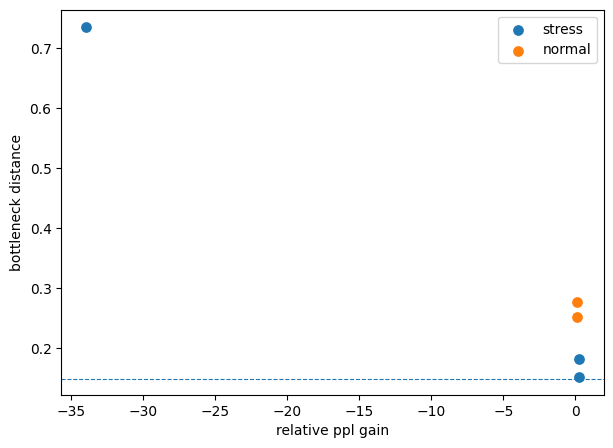

In [5]:
obs = [r["checks"]["R1_churn"]["observed"] for r in TOPO
       if "R1_churn" in (r.get("checks") or {})
       and "observed" in r["checks"]["R1_churn"]]
gains = [r.get("relative_ppl_gain", 0) for r in TOPO
         if "R1_churn" in (r.get("checks") or {})
         and "observed" in r["checks"]["R1_churn"]]
kinds = ["stress" if r.get("stress_mode") else "normal" for r in TOPO
         if "R1_churn" in (r.get("checks") or {})
         and "observed" in r["checks"]["R1_churn"]]
fig, ax = plt.subplots(figsize=(7, 5))
for kind in set(kinds):
    xs = [g for g, k in zip(gains, kinds) if k == kind]
    ys = [o for o, k in zip(obs, kinds) if k == kind]
    ax.scatter(xs, ys, label=kind, s=45)
import yaml
cfg = yaml.safe_load((REPO / "config.yaml").read_text(encoding="utf-8"))
ax.axhline(cfg["topo"]["churn_bottleneck"], ls="--", lw=0.8)
ax.set_xlabel("relative ppl gain"); ax.set_ylabel("bottleneck distance")
ax.legend(); save_figure(fig, "nb7_ppl_vs_bottleneck"); plt.show()

## Interpretation and limits

- What the measured divergence rates do and do not establish: round count is small, one model, one seed, one geometry policy.
- Thresholds were frozen before S1 (commit `chore(v2): freeze thresholds before stress`); any post-hoc tuning marks the experiment invalid (config_sha256 audit).
- Divergence without a damage verdict proves a difference of criteria, not that the veto is right.
- The veto is a guardrail, not a proof of quality.